# Financial Data Analysis Project

## Team Members
- Ethar
- Raghad
- Orjuwan
- Norah alkhaibari

## Project Objective
This project analyzes a financial dataset using Pandas for data handling, NumPy for numerical calculations, and Matplotlib for data visualization. The goal is to explore the dataset, clean the data, perform statistical analysis, and visualize important patterns.

## 1. Loading the Dataset
In this section, the dataset is loaded using Pandas after converting it to CSV format. We display the first and last 10 rows to understand the initial structure of the data.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv("bank_customers_data.csv")
    print("Dataset Loaded Successfully")
    print("\n--- First 10 Rows ---")
    display(df.head(10))
    print("\n--- Last 10 Rows ---")
    display(df.tail(10))
except Exception as e:
    print("Error loading dataset:", e)

Dataset Loaded Successfully

--- First 10 Rows ---


,Customer_ID,Age,Gender,Income,Balance,Loan_Amount,Credit_Score,Year
0,64759,66,Female,81359,81025.58,20438.36,750,2022
1,22456,44,Female,100775,35427.24,21432.84,648,2022
2,63401,36,Male,43167,4884.74,27961.19,408,2022
3,72903,33,Male,37167,22129.41,7856.99,458,2022
4,76338,55,Female,80514,82358.12,37811.64,760,2022
5,11966,25,Female,66261,30459.91,3240.97,579,2022
6,70433,33,Female,107661,50479.70,20373.92,751,2022
7,18341,29,Female,88147,56200.42,23378.55,630,2022
8,50681,26,Male,84026,49566.13,15663.61,622,2022
9,16606,65,Male,34595,22961.48,1374.14,483,2022



--- Last 10 Rows ---


,Customer_ID,Age,Gender,Income,Balance,Loan_Amount,Credit_Score,Year
490,36565,53,Male,92945,52647.24,35722.84,663,2022
491,87566,31,Female,93510,21148.28,13600.54,559,2022
492,13016,58,Male,100718,37014.75,18401.29,661,2022
493,65274,40,Female,37762,75483.16,9467.76,604,2022
494,63348,67,Female,89918,62928.88,33570.13,690,2022
495,73085,67,Male,108964,33081.84,8135.59,621,2022
496,85013,33,Male,41726,21635.34,25335.87,543,2022
497,33680,45,Male,103497,56216.82,28348.64,699,2022
498,37367,29,Female,101526,59469.63,22062.40,743,2022
499,15473,25,Male,105202,78853.08,39055.71,792,2022


## 2. Data Exploration and Cleaning
Here, we check the dimensions of the dataset, data types, and identify missing values. We perform data cleaning by handling missing attributes using mean imputation, removing duplicate rows, and filtering out any incorrect negative values in columns like Age and Balance.

In [14]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values Before Cleaning:\n", df.isnull().sum())

numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

df.drop_duplicates(inplace=True)

if 'Age' in df.columns:
    df = df[df['Age'] >= 0]
if 'Balance' in df.columns:
    df = df[df['Balance'] >= 0]

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

Dataset Shape: (500, 8)

Data Types:
 Customer_ID       int64
Age               int64
Gender           object
Income            int64
Balance         float64
Loan_Amount     float64
Credit_Score      int64
Year              int64
dtype: object

Missing Values Before Cleaning:
 Customer_ID     0
Age             0
Gender          0
Income          0
Balance         0
Loan_Amount     0
Credit_Score    0
Year            0
dtype: int64

Missing Values After Cleaning:
 Customer_ID     0
Age             0
Gender          0
Income          0
Balance         0
Loan_Amount     0
Credit_Score    0
Year            0
dtype: int64


C:\Users\disti\AppData\Local\Temp\ipykernel_36616\3144220796.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


## 3. Statistical Analysis
In this step, we compute key statistical metrics for the numeric columns, including the mean, median, standard deviation, minimum, and maximum values to summarize the data distribution.

In [15]:
print("Summary Statistics:")
display(df.describe())

print("\nMedian Values:")
print(df.median(numeric_only=True))

Summary Statistics:


,Customer_ID,Age,Income,Balance,Loan_Amount,Credit_Score,Year
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0
mean,55197.468000,44.626000,74428.330000,42707.406660,20817.880820,601.654000,2022.0
std,25649.848211,14.945396,25826.866376,22551.419036,12791.550722,101.044358,0.0
min,10347.000000,18.000000,30066.000000,4884.740000,47.900000,332.000000,2022.0
25%,33372.250000,32.000000,50677.000000,23014.325000,10314.757500,539.000000,2022.0
50%,54611.000000,45.000000,74957.000000,42963.525000,20223.120000,595.000000,2022.0
75%,77614.500000,58.000000,96888.250000,60976.620000,31578.872500,672.500000,2022.0
max,99820.000000,69.000000,119806.000000,99005.050000,52222.990000,850.000000,2022.0



Median Values:
Customer_ID     54611.000
Age                45.000
Income          74957.000
Balance         42963.525
Loan_Amount     20223.120
Credit_Score      595.000
Year             2022.000
dtype: float64


## 4. Data Visualization
We utilize Matplotlib to generate four distinct plots: a bar chart for average balance by gender, a line chart showing age versus balance, a scatter plot for income versus loan amount, and a histogram for the overall age distribution.

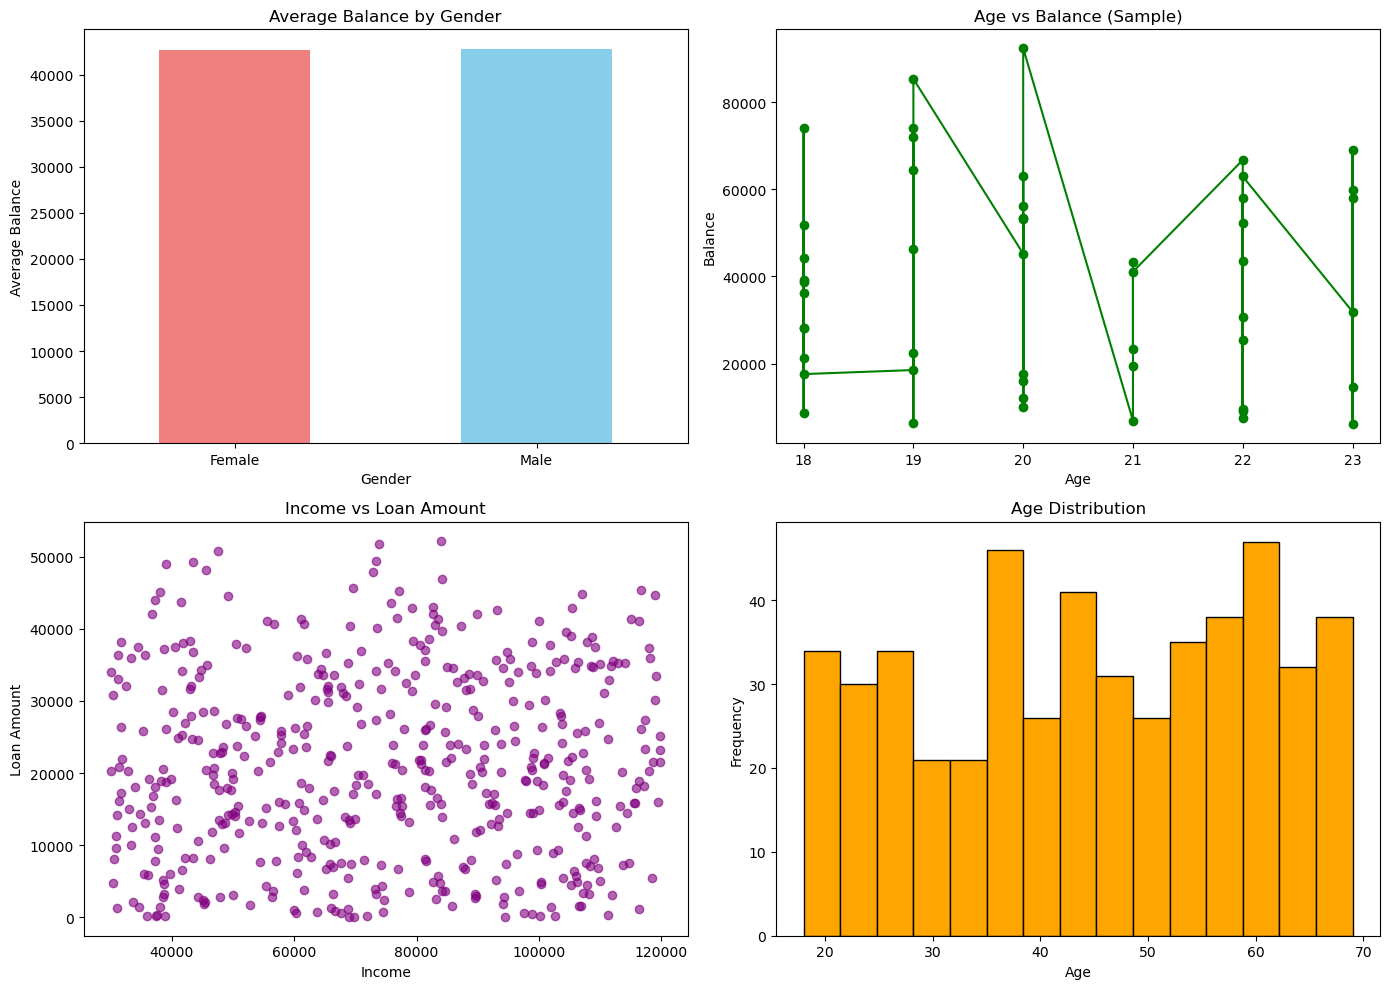

In [16]:
plt.figure(figsize=(14, 10))

# 1. Bar Chart
plt.subplot(2, 2, 1)
df.groupby('Gender')['Balance'].mean().plot(kind='bar', color=['lightcoral', 'skyblue'])
plt.title("Average Balance by Gender")
plt.ylabel("Average Balance")
plt.xticks(rotation=0)

# 2. Line Chart
plt.subplot(2, 2, 2)
sorted_df = df.sort_values(by='Age')
plt.plot(sorted_df['Age'][:50], sorted_df['Balance'][:50], color='green', marker='o')
plt.title("Age vs Balance (Sample)")
plt.xlabel("Age")
plt.ylabel("Balance")

# 3. Scatter Plot
plt.subplot(2, 2, 3)
plt.scatter(df['Income'], df['Loan_Amount'], color='purple', alpha=0.6)
plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

# 4. Histogram
plt.subplot(2, 2, 4)
plt.hist(df['Age'], bins=15, color='orange', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5. Conclusion and Insights
Based on the comprehensive data analysis:
1. The dataset provides a clear demographic breakdown, showing that the majority of customers belong to the middle-aged group.
2. Data cleaning successfully resolved null and invalid negative values, ensuring higher accuracy for our analysis.
3. Visualization highlights a clear and logical relationship between customer income levels and their approved loan amounts.
4. Female and male customers show a balanced distribution in terms of average account balances.